In [1]:
import numpy as np
from tensorflow.keras.optimizers import Adam
from keras.layers import Activation, Dropout, Convolution2D, GlobalAveragePooling2D
from keras.models import Sequential
import tensorflow as tf
import tensorflow.keras.applications.mobilenet
import os
import PIL
import cv2
import keras
import matplotlib.pyplot as plt
from keras import layers
from keras import Model
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau


def preprocess(new_path,size):
    imgpath=PIL.Image.open(new_path)
    imgpath=imgpath.convert('RGB')
    img = np.asarray(imgpath)
    img = cv2.resize(img, (size,size))
    img=img/255.
    return img
IMG_Angle="2.jpeg"
IMG_Part="1.jpg"
data1=preprocess(IMG_Angle,331)
data2=preprocess(IMG_Part,224)

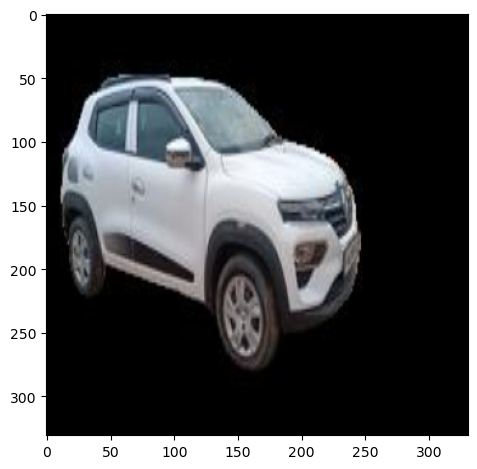

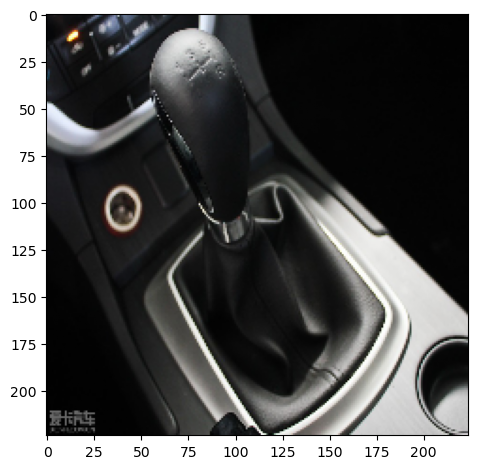

In [2]:
plt.imshow(data1) 
plt.tight_layout()
plt.show()
plt.imshow(data2) 
plt.tight_layout()
plt.show()

In [4]:
modelangle = tf.keras.models.load_model('model.keras')
modelangle.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 331, 331, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_209 (Conv2D)           │ (None, 165, 165, 32)      │             864 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_203       │ (None, 165, 165, 32)      │              96 │ conv2d_209[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_209 (Activation)   │ (None, 165, 165, 32)      │               0 │ batch_normalization_203[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_210 (Conv2D)           │ (None, 163, 163, 32)      │           9,216 │ activation_209[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_204       │ (None, 163, 163, 32)      │              96 │ conv2d_210[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_210 (Activation)   │ (None, 163, 163, 32)      │               0 │ batch_normalization_204[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_211 (Conv2D)           │ (None, 163, 163, 64)      │          18,432 │ activation_210[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_205       │ (None, 163, 163, 64)      │             192 │ conv2d_211[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_211 (Activation)   │ (None, 163, 163, 64)      │               0 │ batch_normalization_205[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_10              │ (None, 81, 81, 64)        │               0 │ activation_211[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_212 (Conv2D)           │ (None, 81, 81, 80)        │           5,120 │ max_pooling2d_10[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_206       │ (None, 81, 81, 80)        │             240 │ conv2d_212[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_212 (Activation)   │ (None, 81, 81, 80)        │               0 │ batch_normalization_206[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_213 (Conv2D)           │ (None, 79, 79, 192)       │         138,24

 Total params: 395,543,322 (1.47 GB)

 Trainable params: 113,735,528 (433.87 MB)

 Non-trainable params: 54,336,736 (207.28 MB)

 Optimizer params: 227,471,058 (867.73 MB)

In [5]:
modelpart = tf.keras.models.load_model('CarPartINExmodel.h5')
modelpart.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 66,912,202 (255.25 MB)

 Trainable params: 64,654,216 (246.64 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [10]:

xtest=[data1]
xtest=np.array(xtest)
xtest1=[data2]
xtest1=np.array(xtest1)

In [11]:
xtest.shape

(1, 331, 331, 3)

In [12]:
Y_pred = modelangle.predict([xtest,xtest])


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [14]:
Y_pred_part = modelpart.predict(xtest1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [15]:
# Convert predictions classes to one hot vectors 
Y_pred_classes_angle = np.argmax(Y_pred,axis = 1) 
Y_pred_classes_part = np.argmax(Y_pred_part,axis = 1) 

Gear stick


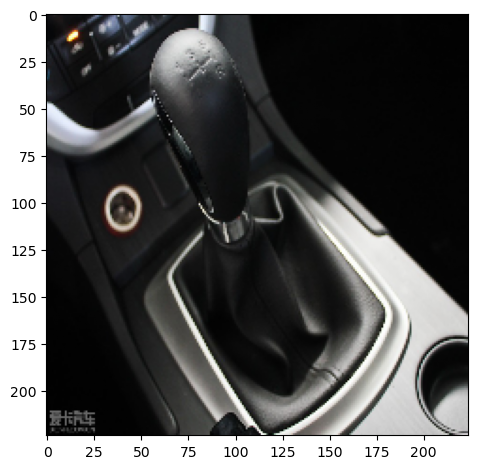

In [18]:
label=['Air intake',
 'Console',
 'Dashboard',
 'Fog light',
 'Gear stick',
 'Headlight',
 'Steering wheel',
 'Tail light']
print(label[Y_pred_classes_part[0]])
plt.imshow(data2) 
plt.tight_layout()
plt.show()


rear_right - 320


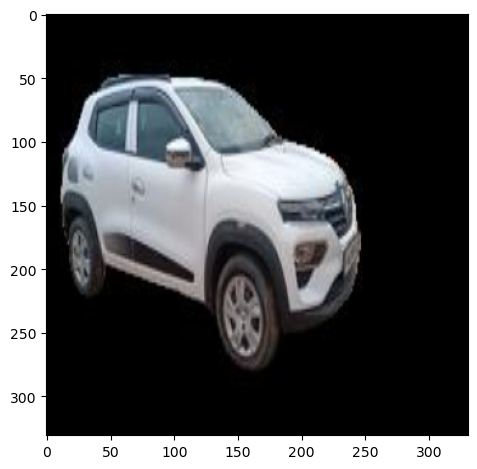

In [17]:
label= {'0': 0, '130': 1, '180': 2, '230': 3, '270': 4, '320': 5, '40': 6, '90': 7}
angle_mapping = {
    "right": 0,
    "front_left": 130,
    "left": 180,
    "rear_left": 230,
    "rear": 270,
    "rear_right": 320,
    "front_right": 40,
    "front": 90
}
angle_to_name = {v: k for k, v in angle_mapping.items()}
index_to_angle = {v: k for k, v in label.items()}

# Example: get value from prediction
pred_index = Y_pred_classes_angle[0]
angle_value = int(index_to_angle[pred_index])
print(angle_to_name[angle_value] +" - " + str(angle_value) )
plt.imshow(data1) 
plt.tight_layout()
plt.show()
